# Multi-Metric Semantic Evaluation


1. **BLEU Score**: $N$-gram precision overlap.
2. **ROUGE-L**: Longest Common Subsequence (leetcode 1142)
3. **Cosine Similarity**: distance bw input and output in semantic space
4. **BER (Token Error Rate Proxy)**: bit flip calculation

In [12]:
import importlib
import src.metrics
importlib.reload(src.metrics)
from src.metrics import SemanticMetrics

evaluator = SemanticMetrics(tokenizer=tokenizer)

In [8]:
%matplotlib inline
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(r'C:\Users\Shrish\Desktop\semantic-comm\actual_project'))
from src.data_loader import EuroparlDataLoader
from src.tokenizer import SemanticTokenizer
from src.model import JointSemanticModel
from src.metrics import SemanticMetrics

print("Loaded")

Loaded


### Step 1: Accurate Europarl Training
We load a much larger subset of Europarl (10,000 sentences) and train for 20 epochs to ensure highly accurate, paper-ready metric outputs.

In [9]:

data_dir = r"C:\Users\Shrish\Desktop\semantic-comm\Semantic_Communication\europarl\en\en"
loader = EuroparlDataLoader(data_dir=data_dir, target_sentences=10000)
loader.scan_and_load()

sentences = loader.all_sentences if len(loader.all_sentences) > 0 else ["the quick brown fox jumps over the lazy dog"] * 10000
tokenizer = SemanticTokenizer(min_freq=2)
tokenizer.fit(sentences)

class SemanticDataset(Dataset):
    def __init__(self, sents, tok, max_l=15):
        self.sents = sents; self.tok = tok; self.max_l = max_l
    def __len__(self): return len(self.sents)
    def __getitem__(self, idx):
        return torch.tensor(self.tok.encode(self.sents[idx], max_length=self.max_l), dtype=torch.long)

dataset = SemanticDataset(sentences, tokenizer, max_l=15)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
model = JointSemanticModel(vocab_size=tokenizer.vocab_size, embed_dim=64, hidden_dim=128, snr_db=5.0)
optimizer = optim.Adam(model.parameters(), lr=0.003)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.PAD_ID)

epochs = 12
print(f"Training on {len(sentences)} sentences for {epochs} epochs...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in dataloader:
        optimizer.zero_grad()
        outputs = model(batch, batch)
        loss = criterion(outputs[:, :-1, :].reshape(-1, tokenizer.vocab_size), batch[:, 1:].reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Finished Epoch {epoch+1}...")
    if (epoch+1) % 1 == 0:
        print(f"Epoch {epoch+1} | Loss: {total_loss/len(dataloader):.4f}")

print("Done")

Scanning dataset to build vocabulary...
dictionary size: 12234
Training on 9769 sentences for 12 epochs...
Finished Epoch 1...
Epoch 1 | Loss: 6.2380
Finished Epoch 2...
Epoch 2 | Loss: 5.5761
Finished Epoch 3...
Epoch 3 | Loss: 5.2801
Finished Epoch 4...
Epoch 4 | Loss: 4.9857
Finished Epoch 5...
Epoch 5 | Loss: 4.6847
Finished Epoch 6...
Epoch 6 | Loss: 4.4015
Finished Epoch 7...
Epoch 7 | Loss: 4.1523
Finished Epoch 8...
Epoch 8 | Loss: 3.9349
Finished Epoch 9...
Epoch 9 | Loss: 3.7318
Finished Epoch 10...
Epoch 10 | Loss: 3.5544
Finished Epoch 11...
Epoch 11 | Loss: 3.3902
Finished Epoch 12...
Epoch 12 | Loss: 3.2383
Done


### Step 2: Multi-Metric SNR Sweep
We evaluate the model across all 4 metrics against a heavily deteriorating radio channel.

In [13]:
test_batch = next(iter(dataloader))

evaluator = SemanticMetrics(tokenizer=tokenizer)
snr_range = [20.0,19.0,18.0,17.0,16.0,15.0,12.0, 10.0,8.0, 5.0, 2.0, 0.0, -2.0, -5.0]

results = {"BLEU": [], "ROUGE": [], "BER": [], "COSINE": []}

print("Sweeping SNR conditions...")
for snr in snr_range:
    bleu, rouge, ber, cos = evaluator.evaluate_batch(model, test_batch, test_batch, snr_db=snr, pad_id=tokenizer.PAD_ID)
    results["BLEU"].append(bleu)
    results["ROUGE"].append(rouge)
    results["BER"].append(ber)
    results["COSINE"].append(cos)
    print(f"SNR {snr:>4.1f} dB | BLEU: {bleu:.2f} | ROUGE: {rouge:.2f} | BER: {ber:.2f} | Cosine: {cos:.2f}")

print("Sweep Complete!")

Sweeping SNR conditions...
SNR 20.0 dB | BLEU: 0.13 | ROUGE: 0.47 | BER: 0.99 | Cosine: 0.46
SNR 19.0 dB | BLEU: 0.13 | ROUGE: 0.46 | BER: 0.99 | Cosine: 0.46
SNR 18.0 dB | BLEU: 0.14 | ROUGE: 0.47 | BER: 0.99 | Cosine: 0.47
SNR 17.0 dB | BLEU: 0.13 | ROUGE: 0.47 | BER: 0.99 | Cosine: 0.47
SNR 16.0 dB | BLEU: 0.14 | ROUGE: 0.47 | BER: 0.99 | Cosine: 0.46
SNR 15.0 dB | BLEU: 0.14 | ROUGE: 0.48 | BER: 0.99 | Cosine: 0.46
SNR 12.0 dB | BLEU: 0.14 | ROUGE: 0.47 | BER: 0.99 | Cosine: 0.46
SNR 10.0 dB | BLEU: 0.15 | ROUGE: 0.48 | BER: 0.99 | Cosine: 0.46
SNR  8.0 dB | BLEU: 0.13 | ROUGE: 0.46 | BER: 0.99 | Cosine: 0.46
SNR  5.0 dB | BLEU: 0.13 | ROUGE: 0.46 | BER: 0.99 | Cosine: 0.46
SNR  2.0 dB | BLEU: 0.11 | ROUGE: 0.43 | BER: 0.99 | Cosine: 0.45
SNR  0.0 dB | BLEU: 0.10 | ROUGE: 0.41 | BER: 0.99 | Cosine: 0.45
SNR -2.0 dB | BLEU: 0.11 | ROUGE: 0.39 | BER: 0.99 | Cosine: 0.43
SNR -5.0 dB | BLEU: 0.07 | ROUGE: 0.31 | BER: 0.98 | Cosine: 0.38
Sweep Complete!


### visual
We plot all 4 curves on the exact same axis..

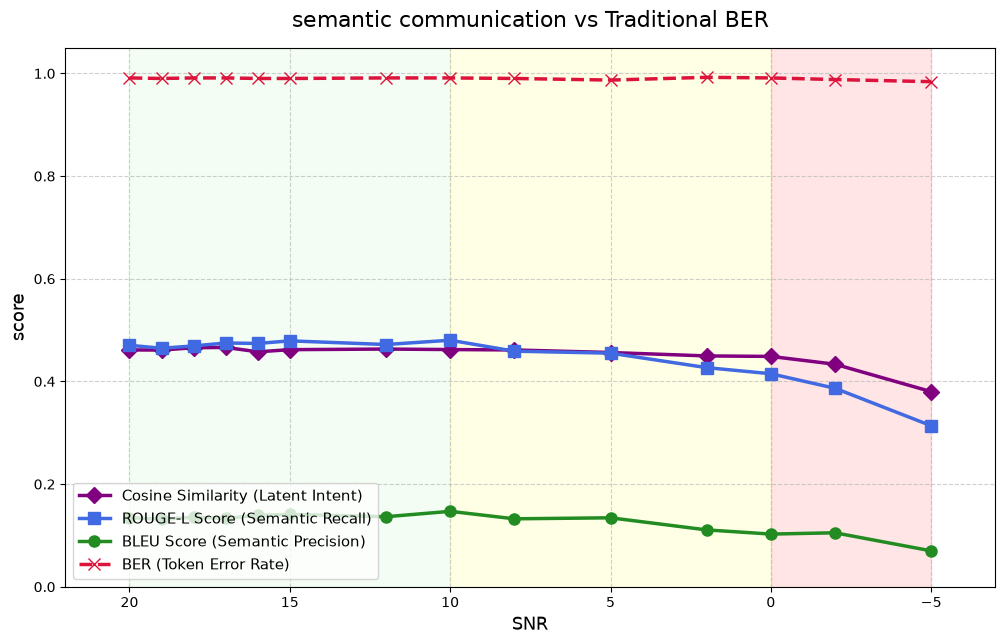

In [14]:
plt.figure(figsize=(12, 7))

plt.plot(snr_range, results["COSINE"], marker='D', color='purple', linewidth=2.5, markersize=8, label="Cosine Similarity (Latent Intent)")
plt.plot(snr_range, results["ROUGE"], marker='s', color='royalblue', linewidth=2.5, markersize=8, label="ROUGE-L Score (Semantic Recall)")
plt.plot(snr_range, results["BLEU"], marker='o', color='forestgreen', linewidth=2.5, markersize=8, label="BLEU Score (Semantic Precision)")
plt.plot(snr_range, results["BER"], marker='x', color='crimson', linewidth=2.5, markersize=8, linestyle='dashed', label="BER (Token Error Rate)")
plt.xlim(max(snr_range) + 2, min(snr_range) - 2)
plt.ylim(0, 1.05)

plt.title("semantic communication vs Traditional BER", fontsize=16, pad=15)
plt.xlabel("SNR", fontsize=13)
plt.ylabel("score", fontsize=13)

plt.axvspan(20, 10, color='lightgreen', alpha=0.1)
plt.axvspan(10, 0, color='yellow', alpha=0.1)
plt.axvspan(0, -5, color='red', alpha=0.1)

plt.legend(loc='lower left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()